# Phase 4 — Model Explainability and Error Analysis

- **4A.** Validate model and test artifacts
- **4B.** Global importance
- **4C.** SHAP summary
- **4D.** Focused error analysis and readiness conclusion

## **4A.** Load and validate the saved model artifacts

Phase 3 selected and saved the final forecasting strategy:

- current-value persistence for horizons 1 through 12
- the saved `xgboost_shallower` model for horizons 13 through 72

Before generating feature explanations, the saved artifact package must be
verified.

This subphase confirms that:

- the saved model loads successfully
- the ordered feature contract is available
- model metadata and test reports can be read
- the test dataset contains every required model feature
- target and identifier columns are not passed into the model
- saved test predictions align with the test dataset
- the hybrid prediction rule is reproduced exactly
- the saved test metrics can be reproduced without retraining

No model fitting or tuning is performed.

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


PROJECT_ROOT = Path.cwd().parent

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
TRAINING_DATA_DIR = PROJECT_ROOT / "data" / "training"


BEST_MODEL_PATH = (
    MODELS_DIR
    / "best_model.joblib"
)

MODEL_FEATURE_COLUMNS_PATH = (
    MODELS_DIR
    / "model_feature_columns.json"
)

MODEL_METADATA_PATH = (
    MODELS_DIR
    / "model_metadata.json"
)

MODEL_SELECTION_REPORT_PATH = (
    MODELS_DIR
    / "model_selection_report.json"
)

TEST_DATASET_PATH = (
    TRAINING_DATA_DIR
    / "test_dataset.parquet"
)

TEST_PREDICTIONS_PATH = (
    REPORTS_DIR
    / "test_predictions.parquet"
)

TEST_METRICS_PATH = (
    REPORTS_DIR
    / "test_metrics.json"
)

METRICS_BY_HORIZON_PATH = (
    REPORTS_DIR
    / "metrics_by_horizon.csv"
)

METRICS_BY_HORIZON_GROUP_PATH = (
    REPORTS_DIR
    / "metrics_by_horizon_group.csv"
)


print("Project root:", PROJECT_ROOT)
print("Models directory:", MODELS_DIR)
print("Reports directory:", REPORTS_DIR)
print("Training data directory:", TRAINING_DATA_DIR)

Project root: /home/riyan/Riyan/projects/pearls-aqi-predictor
Models directory: /home/riyan/Riyan/projects/pearls-aqi-predictor/models
Reports directory: /home/riyan/Riyan/projects/pearls-aqi-predictor/reports
Training data directory: /home/riyan/Riyan/projects/pearls-aqi-predictor/data/training


## Confirm Phase 3 artifact availability

Explainability must use the same model and datasets that were validated during
Phase 3.

The notebook therefore checks every required artifact before loading any data.

If an artifact is missing, the analysis should stop rather than silently use a
different model, feature list, or prediction file.

In [2]:
required_artifact_paths = {
    "best model": BEST_MODEL_PATH,
    "model feature contract": MODEL_FEATURE_COLUMNS_PATH,
    "model metadata": MODEL_METADATA_PATH,
    "model selection report": MODEL_SELECTION_REPORT_PATH,
    "test dataset": TEST_DATASET_PATH,
    "test predictions": TEST_PREDICTIONS_PATH,
    "test metrics": TEST_METRICS_PATH,
    "metrics by horizon": METRICS_BY_HORIZON_PATH,
    "metrics by horizon group": METRICS_BY_HORIZON_GROUP_PATH,
}

artifact_status_df = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "path": str(artifact_path),
            "exists": artifact_path.exists(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.exists()
                else None
            ),
        }
        for artifact_name, artifact_path
        in required_artifact_paths.items()
    ]
)

display(artifact_status_df)


missing_artifacts = artifact_status_df.loc[
    ~artifact_status_df["exists"],
    "artifact",
].tolist()

assert not missing_artifacts, (
    "Missing required Phase 3 artifacts: "
    f"{missing_artifacts}"
)

print("All required Phase 3 artifacts exist.")

,artifact,path,exists,size_bytes
0,best model,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,677236
1,model feature contract,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,1653
2,model metadata,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,5609
3,model selection report,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,4088
4,test dataset,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,454151
5,test predictions,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,1754978
6,test metrics,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,732
7,metrics by horizon,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,8181
8,metrics by horizon group,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True,622


All required Phase 3 artifacts exist.


## Load the saved model contract

The saved feature contract defines the exact feature order expected by the
model.

This order must be preserved because tree models associate each input position
with a specific feature learned during training.

The metadata also records:

- the selected hybrid routing rule
- the target column
- the trained XGBoost model name
- the persistence threshold
- data ranges and row counts
- saved validation and test metrics

In [3]:
with open(
    MODEL_FEATURE_COLUMNS_PATH,
    "r",
    encoding="utf-8",
) as file:
    model_feature_contract = json.load(file)

with open(
    MODEL_METADATA_PATH,
    "r",
    encoding="utf-8",
) as file:
    model_metadata = json.load(file)

with open(
    MODEL_SELECTION_REPORT_PATH,
    "r",
    encoding="utf-8",
) as file:
    model_selection_report = json.load(file)

with open(
    TEST_METRICS_PATH,
    "r",
    encoding="utf-8",
) as file:
    saved_test_metrics = json.load(file)


MODEL_FEATURE_COLUMNS = model_feature_contract[
    "feature_columns"
]

TARGET_COLUMN = model_feature_contract[
    "target_column"
]

IDENTIFIER_COLUMNS = model_feature_contract[
    "identifier_columns"
]

PERSISTENCE_MAX_HORIZON = int(
    model_metadata["routing"][
        "persistence_max_horizon"
    ]
)

SELECTED_STRATEGY_NAME = (
    model_metadata["selected_strategy"]
)

SAVED_XGBOOST_MODEL_NAME = (
    model_metadata["model_name"]
)


print("Number of model features:", len(MODEL_FEATURE_COLUMNS))
print("Target column:", TARGET_COLUMN)
print("Identifier columns:", IDENTIFIER_COLUMNS)
print("Selected strategy:", SELECTED_STRATEGY_NAME)
print("Saved XGBoost model:", SAVED_XGBOOST_MODEL_NAME)
print(
    "Persistence maximum horizon:",
    PERSISTENCE_MAX_HORIZON,
)

Number of model features: 56
Target column: target_pm25_ug_m3
Identifier columns: ['reference_time', 'target_time']
Selected strategy: hybrid_persistence_1_12_xgboost_shallower_13_72
Saved XGBoost model: xgboost_shallower
Persistence maximum horizon: 12


In [4]:
routing_summary_df = pd.DataFrame(
    [
        {
            "horizon_range": "1-12",
            "prediction_method": (
                model_metadata["routing"][
                    "horizons_1_to_12"
                ]
            ),
        },
        {
            "horizon_range": "13-72",
            "prediction_method": (
                model_metadata["routing"][
                    "horizons_13_to_72"
                ]
            ),
        },
    ]
)

display(routing_summary_df)

,horizon_range,prediction_method
0,1-12,current_pm25_persistence
1,13-72,xgboost_shallower


## Load the selected XGBoost estimator

The saved Joblib file contains the fitted XGBoost estimator selected during
Phase 3.

The model is loaded directly from disk.

It is not refitted, updated, or tuned in Phase 4.

In [5]:
saved_model = joblib.load(
    BEST_MODEL_PATH
)

print("Loaded model type:", type(saved_model).__name__)
print("Loaded model class:", type(saved_model))

Loaded model type: XGBRegressor
Loaded model class: <class 'xgboost.sklearn.XGBRegressor'>


In [6]:
assert type(saved_model).__name__ == "XGBRegressor"

assert SAVED_XGBOOST_MODEL_NAME == "xgboost_shallower"

assert PERSISTENCE_MAX_HORIZON == 12

assert TARGET_COLUMN not in MODEL_FEATURE_COLUMNS

for identifier_column in IDENTIFIER_COLUMNS:
    assert identifier_column not in MODEL_FEATURE_COLUMNS

assert "forecast_horizon_hours" in MODEL_FEATURE_COLUMNS

print("Saved model identity and routing configuration validated.")

Saved model identity and routing configuration validated.


## Load the final chronological test artifacts

The test dataset represents the untouched chronological period used for final
Phase 3 evaluation.

The saved prediction file contains the hybrid results generated during that
evaluation.

Both files are loaded so their row alignment, keys, targets, and predictions can
be checked before explanation.

In [7]:
test_df = pd.read_parquet(
    TEST_DATASET_PATH
)

saved_test_predictions_df = pd.read_parquet(
    TEST_PREDICTIONS_PATH
)

metrics_by_horizon_df = pd.read_csv(
    METRICS_BY_HORIZON_PATH
)

metrics_by_horizon_group_df = pd.read_csv(
    METRICS_BY_HORIZON_GROUP_PATH
)


print("Test dataset shape:", test_df.shape)
print(
    "Saved test predictions shape:",
    saved_test_predictions_df.shape,
)
print(
    "Metrics by horizon shape:",
    metrics_by_horizon_df.shape,
)
print(
    "Metrics by horizon group shape:",
    metrics_by_horizon_group_df.shape,
)

Test dataset shape: (76813, 59)
Saved test predictions shape: (76813, 12)
Metrics by horizon shape: (72, 6)
Metrics by horizon group shape: (5, 6)


## Validate test feature availability

Every feature listed in the saved model contract must exist in the test
dataset.

The target and identifier columns must also exist for evaluation, but they are
kept separate from model inputs.

No missing feature values are permitted because the model was trained only on
complete rows.

In [8]:
missing_model_features = [
    column
    for column in MODEL_FEATURE_COLUMNS
    if column not in test_df.columns
]

required_non_feature_columns = [
    *IDENTIFIER_COLUMNS,
    TARGET_COLUMN,
]

missing_non_feature_columns = [
    column
    for column in required_non_feature_columns
    if column not in test_df.columns
]


print("Missing model features:", missing_model_features)
print(
    "Missing target or identifier columns:",
    missing_non_feature_columns,
)


assert not missing_model_features
assert not missing_non_feature_columns

assert (
    test_df[MODEL_FEATURE_COLUMNS]
    .isna()
    .sum()
    .sum()
    == 0
)

assert test_df[TARGET_COLUMN].isna().sum() == 0

print("Test feature and target schema validated.")

Missing model features: []
Missing target or identifier columns: []


Test feature and target schema validated.


In [9]:
duplicate_test_keys = (
    test_df[
        [
            "reference_time",
            "forecast_horizon_hours",
        ]
    ]
    .duplicated()
    .sum()
)

duplicate_prediction_keys = (
    saved_test_predictions_df[
        [
            "reference_time",
            "forecast_horizon_hours",
        ]
    ]
    .duplicated()
    .sum()
)


print("Duplicate test dataset keys:", duplicate_test_keys)
print(
    "Duplicate saved prediction keys:",
    duplicate_prediction_keys,
)


assert duplicate_test_keys == 0
assert duplicate_prediction_keys == 0

print("Test row keys are unique.")

Duplicate test dataset keys: 0
Duplicate saved prediction keys: 0
Test row keys are unique.


## Confirm one-to-one alignment between test rows and predictions

The saved prediction file must correspond exactly to the test dataset.

Alignment is checked using:

`reference_time + forecast_horizon_hours`

This prevents explanations from being attached to the wrong target row.

In [10]:
test_alignment_columns = [
    "reference_time",
    "forecast_horizon_hours",
    "target_time",
    TARGET_COLUMN,
]

test_alignment_df = (
    test_df[test_alignment_columns]
    .reset_index(drop=True)
)

saved_alignment_df = (
    saved_test_predictions_df[
        test_alignment_columns
    ]
    .reset_index(drop=True)
)


pd.testing.assert_frame_equal(
    test_alignment_df,
    saved_alignment_df,
    check_dtype=True,
)

print(
    "Saved predictions align one-to-one with the test dataset."
)

Saved predictions align one-to-one with the test dataset.


## Reproduce the saved XGBoost predictions

The saved XGBoost estimator is applied to the test features in the exact order
specified by the feature contract.

This confirms that the saved model produces the same long-horizon predictions
recorded during Phase 3.

No model fitting occurs.

In [11]:
X_test = test_df[
    MODEL_FEATURE_COLUMNS
]

y_test = test_df[
    TARGET_COLUMN
]


assert X_test.columns.tolist() == MODEL_FEATURE_COLUMNS


reproduced_xgboost_predictions = (
    saved_model.predict(
        X_test
    )
)


print(
    "Reproduced XGBoost predictions:",
    len(reproduced_xgboost_predictions),
)

print(
    "Negative XGBoost predictions:",
    int(
        (
            reproduced_xgboost_predictions < 0
        ).sum()
    ),
)

Reproduced XGBoost predictions: 76813
Negative XGBoost predictions: 0


In [12]:
np.testing.assert_allclose(
    reproduced_xgboost_predictions,
    saved_test_predictions_df[
        "xgboost_prediction"
    ].to_numpy(),
    rtol=1e-6,
    atol=1e-6,
)

print(
    "Saved XGBoost predictions reproduced successfully."
)

Saved XGBoost predictions reproduced successfully.


## Reproduce the final hybrid predictions

The final Phase 3 strategy does not use XGBoost for every forecast horizon.

The deterministic routing rule is:

- horizons 1–12 use `pm25_current`
- horizons 13–72 use the saved XGBoost model

The reproduced hybrid predictions must match the saved prediction column
exactly.

In [13]:
reproduced_hybrid_predictions = np.where(
    test_df[
        "forecast_horizon_hours"
    ].to_numpy()
    <= PERSISTENCE_MAX_HORIZON,
    test_df[
        "pm25_current"
    ].to_numpy(),
    reproduced_xgboost_predictions,
)


np.testing.assert_allclose(
    reproduced_hybrid_predictions,
    saved_test_predictions_df[
        "prediction"
    ].to_numpy(),
    rtol=1e-6,
    atol=1e-6,
)

print(
    "Saved hybrid predictions reproduced successfully."
)

Saved hybrid predictions reproduced successfully.


## Reproduce final test metrics

The reproduced hybrid predictions are evaluated using the same metrics as
Phase 3:

- MAE
- RMSE
- R²

The resulting values are compared with the saved test report.

Small floating-point differences are acceptable, but material differences would
indicate an artifact or alignment problem.

In [14]:
def calculate_regression_metrics(
    y_true: pd.Series,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """Calculate standard PM2.5 regression metrics."""

    return {
        "mae": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "rmse": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            )
        ),
        "r2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
    }

In [15]:
reproduced_test_metrics = (
    calculate_regression_metrics(
        y_true=y_test,
        y_pred=reproduced_hybrid_predictions,
    )
)

saved_selected_metrics = (
    saved_test_metrics[
        "selected_strategy_metrics"
    ]
)


metric_comparison_df = pd.DataFrame(
    [
        {
            "metric": metric_name,
            "saved_value": float(
                saved_selected_metrics[metric_name]
            ),
            "reproduced_value": float(
                reproduced_test_metrics[metric_name]
            ),
            "absolute_difference": abs(
                float(
                    saved_selected_metrics[
                        metric_name
                    ]
                )
                - float(
                    reproduced_test_metrics[
                        metric_name
                    ]
                )
            ),
        }
        for metric_name in [
            "mae",
            "rmse",
            "r2",
        ]
    ]
)

display(metric_comparison_df)

,metric,saved_value,reproduced_value,absolute_difference
0,mae,3.715507,3.715507,4.440892e-16
1,rmse,4.975563,4.975563,0.000000e+00
2,r2,-0.003986,-0.003986,0.000000e+00


In [16]:
METRIC_TOLERANCE = 1e-6

assert (
    metric_comparison_df[
        "absolute_difference"
    ]
    <= METRIC_TOLERANCE
).all(), (
    "Reproduced test metrics do not match "
    "the saved Phase 3 metrics."
)

print("Saved Phase 3 test metrics reproduced successfully.")

Saved Phase 3 test metrics reproduced successfully.


## Prepare the explainability and error-analysis table

A single test-analysis table is created for later Phase 4 steps.

Residual is defined as:

`actual PM2.5 - predicted PM2.5`

Therefore:

- positive residual means underprediction
- negative residual means overprediction

Percentage error is calculated only when actual PM2.5 is safely above zero.

In [17]:
phase_4_test_analysis_df = (
    saved_test_predictions_df
    .copy()
)

phase_4_test_analysis_df[
    "actual_pm25"
] = phase_4_test_analysis_df[
    TARGET_COLUMN
]

phase_4_test_analysis_df[
    "predicted_pm25"
] = phase_4_test_analysis_df[
    "prediction"
]

phase_4_test_analysis_df[
    "residual"
] = (
    phase_4_test_analysis_df[
        "actual_pm25"
    ]
    - phase_4_test_analysis_df[
        "predicted_pm25"
    ]
)

phase_4_test_analysis_df[
    "absolute_error"
] = (
    phase_4_test_analysis_df[
        "residual"
    ].abs()
)

phase_4_test_analysis_df[
    "squared_error"
] = (
    phase_4_test_analysis_df[
        "residual"
    ] ** 2
)

SAFE_PERCENTAGE_ERROR_THRESHOLD = 1.0

phase_4_test_analysis_df[
    "percentage_error"
] = np.where(
    phase_4_test_analysis_df[
        "actual_pm25"
    ]
    >= SAFE_PERCENTAGE_ERROR_THRESHOLD,
    (
        phase_4_test_analysis_df[
            "absolute_error"
        ]
        / phase_4_test_analysis_df[
            "actual_pm25"
        ]
        * 100
    ),
    np.nan,
)

phase_4_test_analysis_df[
    "prediction_bias_direction"
] = np.select(
    [
        phase_4_test_analysis_df[
            "residual"
        ] > 0,
        phase_4_test_analysis_df[
            "residual"
        ] < 0,
    ],
    [
        "underprediction",
        "overprediction",
    ],
    default="exact",
)

In [18]:
analysis_summary_df = pd.DataFrame(
    {
        "rows": [
            len(phase_4_test_analysis_df)
        ],
        "mean_actual_pm25": [
            phase_4_test_analysis_df[
                "actual_pm25"
            ].mean()
        ],
        "mean_predicted_pm25": [
            phase_4_test_analysis_df[
                "predicted_pm25"
            ].mean()
        ],
        "mean_residual": [
            phase_4_test_analysis_df[
                "residual"
            ].mean()
        ],
        "mean_absolute_error": [
            phase_4_test_analysis_df[
                "absolute_error"
            ].mean()
        ],
        "underprediction_rate": [
            phase_4_test_analysis_df[
                "prediction_bias_direction"
            ]
            .eq("underprediction")
            .mean()
        ],
        "overprediction_rate": [
            phase_4_test_analysis_df[
                "prediction_bias_direction"
            ]
            .eq("overprediction")
            .mean()
        ],
    }
)

display(analysis_summary_df)

,rows,mean_actual_pm25,mean_predicted_pm25,mean_residual,mean_absolute_error,underprediction_rate,overprediction_rate
0,76813,11.59447,11.475843,0.118627,3.715507,0.459727,0.537461


In [19]:
required_analysis_columns = [
    "reference_time",
    "target_time",
    "forecast_horizon_hours",
    "actual_pm25",
    "predicted_pm25",
    "residual",
    "absolute_error",
    "squared_error",
    "prediction_bias_direction",
]

missing_analysis_columns = [
    column
    for column in required_analysis_columns
    if column not in phase_4_test_analysis_df.columns
]

assert not missing_analysis_columns

assert len(
    phase_4_test_analysis_df
) == len(test_df)

assert (
    phase_4_test_analysis_df[
        required_analysis_columns
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    phase_4_test_analysis_df[
        [
            "actual_pm25",
            "predicted_pm25",
            "residual",
            "absolute_error",
            "squared_error",
        ]
    ].to_numpy()
).all()

print("Phase 4A artifact and metric validation passed.")

Phase 4A artifact and metric validation passed.


## **4B.** Global XGBoost feature importance

The final forecasting strategy is hybrid:

- horizons 1–12 use current PM2.5 persistence
- horizons 13–72 use the saved XGBoost model

Therefore, model-based feature importance is calculated only for the XGBoost
portion of the forecasting system.

Two complementary methods are used:

### XGBoost gain importance

Gain measures how much the model's objective improved when a feature was used
to create tree splits.

It describes how strongly the fitted model relied on each feature, but it does
not show whether higher feature values increase or decrease predictions.

### Permutation importance

Permutation importance measures how much prediction performance deteriorates
when one feature is randomly shuffled.

It is calculated on a representative sample of unseen test rows from horizons
13 through 72.

Neither method proves that a feature causes changes in PM2.5.

In [20]:
EXPLAINABILITY_DIR = (
    PROJECT_ROOT
    / "explainability"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "figures"
)

EXPLAINABILITY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


GLOBAL_IMPORTANCE_PATH = (
    EXPLAINABILITY_DIR
    / "global_feature_importance.csv"
)

PERMUTATION_IMPORTANCE_PATH = (
    EXPLAINABILITY_DIR
    / "permutation_importance.csv"
)

GLOBAL_IMPORTANCE_FIGURE_PATH = (
    FIGURES_DIR
    / "global_feature_importance.png"
)

PERMUTATION_IMPORTANCE_FIGURE_PATH = (
    FIGURES_DIR
    / "permutation_importance.png"
)


print("Explainability directory:", EXPLAINABILITY_DIR)
print("Figures directory:", FIGURES_DIR)

Explainability directory: /home/riyan/Riyan/projects/pearls-aqi-predictor/explainability
Figures directory: /home/riyan/Riyan/projects/pearls-aqi-predictor/figures


### XGBoost gain-based importance

The fitted XGBoost booster stores feature-importance scores.

Gain is used because it summarizes the average improvement produced by splits
involving each feature.

Features that were never used in a tree split may not appear in the raw booster
output. They are added back with an importance value of zero so that all 56
model features remain represented.

In [21]:
xgboost_booster = saved_model.get_booster()

raw_gain_importance = (
    xgboost_booster.get_score(
        importance_type="gain"
    )
)

print(
    "Features used in at least one tree split:",
    len(raw_gain_importance),
)

print(
    "Total features in model contract:",
    len(MODEL_FEATURE_COLUMNS),
)

Features used in at least one tree split: 55
Total features in model contract: 56


In [22]:
gain_importance_df = pd.DataFrame(
    {
        "feature": MODEL_FEATURE_COLUMNS,
        "gain_importance": [
            float(
                raw_gain_importance.get(
                    feature_name,
                    0.0,
                )
            )
            for feature_name
            in MODEL_FEATURE_COLUMNS
        ],
    }
)

total_gain = (
    gain_importance_df[
        "gain_importance"
    ].sum()
)

gain_importance_df[
    "gain_importance_normalized"
] = np.where(
    total_gain > 0,
    (
        gain_importance_df[
            "gain_importance"
        ]
        / total_gain
    ),
    0.0,
)

gain_importance_df = (
    gain_importance_df
    .sort_values(
        "gain_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    gain_importance_df.head(20)
)

,feature,gain_importance,gain_importance_normalized
0,pm25_mean_24h,1.079542e+07,0.219499
1,pm25_mean_12h,1.054656e+07,0.214439
2,pm25_mean_6h,3.325444e+06,0.067615
3,pm25_mean_3h,2.697353e+06,0.054844
4,target_wind_gusts_10m,2.346641e+06,0.047713
5,target_wind_direction_10m_sin,2.098872e+06,0.042676
6,pm25_current,1.599305e+06,0.032518
7,target_hour_cos,1.476633e+06,0.030024
8,reference_month_cos,1.313965e+06,0.026716
9,target_dew_point_2m,1.253369e+06,0.025484


In [23]:
assert len(gain_importance_df) == len(
    MODEL_FEATURE_COLUMNS
)

assert set(
    gain_importance_df["feature"]
) == set(MODEL_FEATURE_COLUMNS)

assert (
    gain_importance_df[
        "gain_importance"
    ] >= 0
).all()

assert np.isclose(
    gain_importance_df[
        "gain_importance_normalized"
    ].sum(),
    1.0,
)

print(
    "XGBoost gain importance validated."
)

XGBoost gain importance validated.


In [24]:
gain_importance_df.to_csv(
    GLOBAL_IMPORTANCE_PATH,
    index=False,
)

print(
    "Saved global feature importance:",
    GLOBAL_IMPORTANCE_PATH,
)

Saved global feature importance: /home/riyan/Riyan/projects/pearls-aqi-predictor/explainability/global_feature_importance.csv


### Plot the most important gain-based features

Only the top 15 features are displayed so the chart remains readable.

The complete ranked list is preserved in the CSV file.

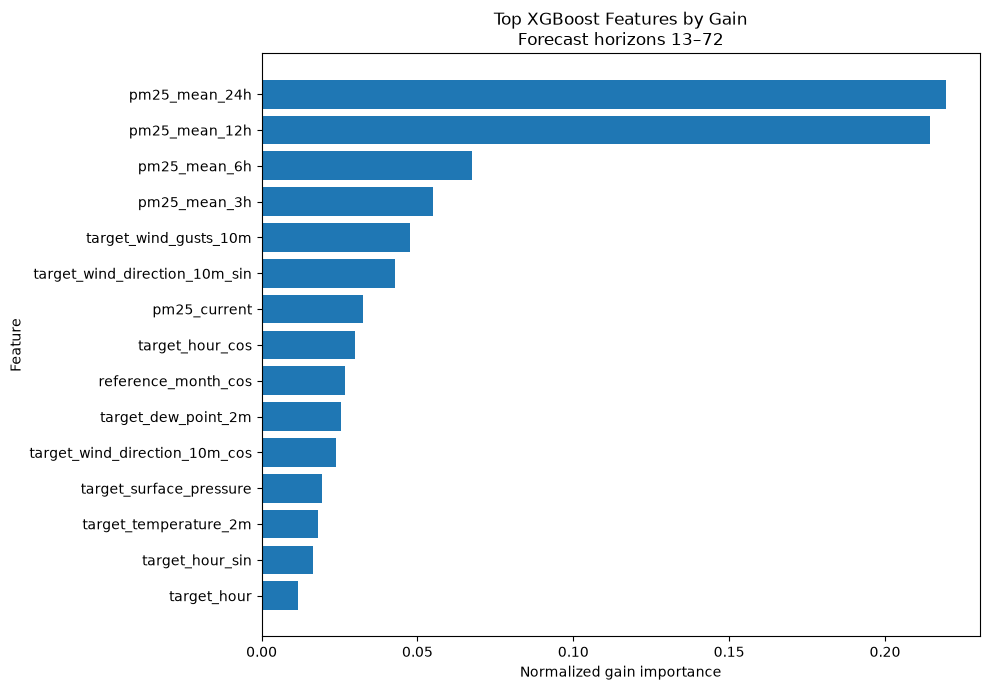

Saved gain-importance figure: /home/riyan/Riyan/projects/pearls-aqi-predictor/figures/global_feature_importance.png


In [25]:
import matplotlib.pyplot as plt


TOP_FEATURE_COUNT = 15

top_gain_features_df = (
    gain_importance_df
    .head(TOP_FEATURE_COUNT)
    .sort_values(
        "gain_importance_normalized",
        ascending=True,
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_gain_features_df["feature"],
    top_gain_features_df[
        "gain_importance_normalized"
    ],
)

plt.xlabel("Normalized gain importance")
plt.ylabel("Feature")
plt.title(
    "Top XGBoost Features by Gain\n"
    "Forecast horizons 13–72"
)

plt.tight_layout()

plt.savefig(
    GLOBAL_IMPORTANCE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved gain-importance figure:",
    GLOBAL_IMPORTANCE_FIGURE_PATH,
)

### Create a representative long-horizon test sample

Permutation importance can be computationally expensive because each feature
must be shuffled and evaluated repeatedly.

A reproducible sample is therefore created from test rows where XGBoost is
actually used.

The sample includes rows from:

- horizons 13–24
- horizons 25–48
- horizons 49–72

Up to 1,000 rows are sampled from each group, producing at most 3,000 rows.

In [26]:
LONG_HORIZON_GROUPS = {
    "13-24h": (13, 24),
    "25-48h": (25, 48),
    "49-72h": (49, 72),
}

PERMUTATION_SAMPLE_PER_GROUP = 1_000
EXPLAINABILITY_RANDOM_SEED = 42

In [27]:
long_horizon_test_df = test_df.loc[
    test_df[
        "forecast_horizon_hours"
    ] > PERSISTENCE_MAX_HORIZON
].copy()


permutation_sample_parts = []

for group_name, (
    minimum_horizon,
    maximum_horizon,
) in LONG_HORIZON_GROUPS.items():
    group_df = long_horizon_test_df.loc[
        long_horizon_test_df[
            "forecast_horizon_hours"
        ].between(
            minimum_horizon,
            maximum_horizon,
        )
    ]

    sample_size = min(
        PERMUTATION_SAMPLE_PER_GROUP,
        len(group_df),
    )

    sampled_group_df = group_df.sample(
        n=sample_size,
        random_state=(
            EXPLAINABILITY_RANDOM_SEED
            + minimum_horizon
        ),
    )

    sampled_group_df = (
        sampled_group_df
        .assign(
            explainability_horizon_group=(
                group_name
            )
        )
    )

    permutation_sample_parts.append(
        sampled_group_df
    )


permutation_sample_df = (
    pd.concat(
        permutation_sample_parts,
        ignore_index=True,
    )
    .sample(
        frac=1.0,
        random_state=EXPLAINABILITY_RANDOM_SEED,
    )
    .reset_index(drop=True)
)


print(
    "Permutation sample rows:",
    len(permutation_sample_df),
)

display(
    permutation_sample_df[
        "explainability_horizon_group"
    ]
    .value_counts()
    .rename("sample_count")
    .to_frame()
)

Permutation sample rows: 3000


,sample_count
explainability_horizon_group,
25-48h,1000
13-24h,1000
49-72h,1000


In [28]:
assert len(permutation_sample_df) <= 3_000

assert (
    permutation_sample_df[
        "forecast_horizon_hours"
    ] > PERSISTENCE_MAX_HORIZON
).all()

assert set(
    permutation_sample_df[
        "explainability_horizon_group"
    ].unique()
) == set(LONG_HORIZON_GROUPS)

assert (
    permutation_sample_df[
        MODEL_FEATURE_COLUMNS
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

print(
    "Representative long-horizon sample validated."
)

Representative long-horizon sample validated.


### Calculate permutation importance

Each feature is shuffled five times.

The scoring metric is negative RMSE because model selection was primarily based
on RMSE.

After converting the result back to a positive interpretation:

- a larger positive value means shuffling the feature increased RMSE more
- a value near zero means shuffling had little measured effect
- a negative value means shuffling happened to improve performance slightly

Negative values can occur because of sampling variation, correlated features,
or weakly useful features.

In [29]:
from time import perf_counter
from sklearn.inspection import (
    permutation_importance,
)


X_permutation = permutation_sample_df[
    MODEL_FEATURE_COLUMNS
]

y_permutation = permutation_sample_df[
    TARGET_COLUMN
]


permutation_start = perf_counter()

permutation_result = permutation_importance(
    estimator=saved_model,
    X=X_permutation,
    y=y_permutation,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=EXPLAINABILITY_RANDOM_SEED,
    n_jobs=-1,
)

permutation_seconds = (
    perf_counter()
    - permutation_start
)


print(
    "Permutation importance completed in "
    f"{permutation_seconds:.2f} seconds."
)

Permutation importance completed in 25.26 seconds.


In [30]:
permutation_importance_df = pd.DataFrame(
    {
        "feature": MODEL_FEATURE_COLUMNS,
        "importance_mean": (
            permutation_result.importances_mean
        ),
        "importance_std": (
            permutation_result.importances_std
        ),
    }
)

permutation_importance_df[
    "importance_positive"
] = (
    permutation_importance_df[
        "importance_mean"
    ].clip(lower=0)
)

positive_importance_total = (
    permutation_importance_df[
        "importance_positive"
    ].sum()
)

permutation_importance_df[
    "importance_normalized"
] = np.where(
    positive_importance_total > 0,
    (
        permutation_importance_df[
            "importance_positive"
        ]
        / positive_importance_total
    ),
    0.0,
)

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    permutation_importance_df.head(20)
)

,feature,importance_mean,importance_std,importance_positive,importance_normalized
0,target_wind_speed_10m,0.346500,0.014151,0.346500,0.333449
1,pm25_current,0.190647,0.010677,0.190647,0.183467
2,target_wind_gusts_10m,0.147059,0.049073,0.147059,0.141520
3,target_wind_direction_10m_cos,0.061224,0.012240,0.061224,0.058918
4,pm25_mean_6h,0.048006,0.007818,0.048006,0.046198
5,target_wind_direction_10m_sin,0.042227,0.008472,0.042227,0.040636
6,pm25_lag_1h,0.035969,0.002665,0.035969,0.034615
7,target_hour_cos,0.035042,0.006812,0.035042,0.033722
8,pm25_mean_3h,0.026151,0.003267,0.026151,0.025166
9,target_wind_direction_10m,0.018402,0.007591,0.018402,0.017709


In [31]:
assert len(
    permutation_importance_df
) == len(MODEL_FEATURE_COLUMNS)

assert set(
    permutation_importance_df["feature"]
) == set(MODEL_FEATURE_COLUMNS)

assert (
    permutation_importance_df[
        [
            "importance_mean",
            "importance_std",
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

permutation_importance_df.to_csv(
    PERMUTATION_IMPORTANCE_PATH,
    index=False,
)

print(
    "Saved permutation importance:",
    PERMUTATION_IMPORTANCE_PATH,
)

Saved permutation importance: /home/riyan/Riyan/projects/pearls-aqi-predictor/explainability/permutation_importance.csv


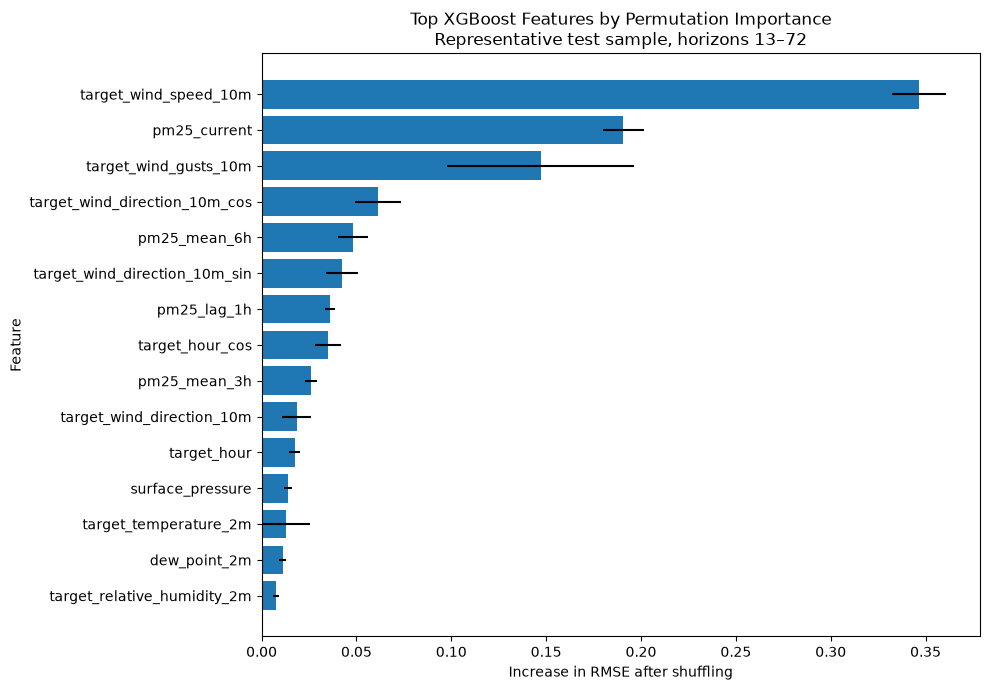

Saved permutation-importance figure: /home/riyan/Riyan/projects/pearls-aqi-predictor/figures/permutation_importance.png


In [32]:
top_permutation_features_df = (
    permutation_importance_df
    .head(TOP_FEATURE_COUNT)
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation_features_df["feature"],
    top_permutation_features_df[
        "importance_mean"
    ],
    xerr=top_permutation_features_df[
        "importance_std"
    ],
)

plt.xlabel(
    "Increase in RMSE after shuffling"
)

plt.ylabel("Feature")

plt.title(
    "Top XGBoost Features by Permutation Importance\n"
    "Representative test sample, horizons 13–72"
)

plt.tight_layout()

plt.savefig(
    PERMUTATION_IMPORTANCE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved permutation-importance figure:",
    PERMUTATION_IMPORTANCE_FIGURE_PATH,
)

### Compare gain and permutation rankings

Gain and permutation importance measure different aspects of model behavior.

A feature can rank highly by gain because it is frequently useful inside the
trees, while its permutation importance may be lower when other correlated
features can partially replace it.

Agreement across both methods gives stronger evidence that a feature is
important to the fitted model.

In [33]:
gain_ranking_df = gain_importance_df[
    [
        "feature",
        "gain_importance",
        "gain_importance_normalized",
    ]
].copy()

gain_ranking_df[
    "gain_rank"
] = (
    gain_ranking_df[
        "gain_importance"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)


permutation_ranking_df = (
    permutation_importance_df[
        [
            "feature",
            "importance_mean",
            "importance_std",
            "importance_normalized",
        ]
    ]
    .copy()
)

permutation_ranking_df[
    "permutation_rank"
] = (
    permutation_ranking_df[
        "importance_mean"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)


importance_comparison_df = (
    gain_ranking_df
    .merge(
        permutation_ranking_df,
        on="feature",
        how="inner",
        validate="one_to_one",
    )
)

importance_comparison_df[
    "average_rank"
] = (
    importance_comparison_df[
        [
            "gain_rank",
            "permutation_rank",
        ]
    ]
    .mean(axis=1)
)

importance_comparison_df = (
    importance_comparison_df
    .sort_values(
        [
            "average_rank",
            "gain_rank",
        ]
    )
    .reset_index(drop=True)
)

display(
    importance_comparison_df.head(20)
)

,feature,gain_importance,gain_importance_normalized,gain_rank,importance_mean,importance_std,importance_normalized,permutation_rank,average_rank
0,pm25_mean_6h,3.325444e+06,0.067615,3,0.048006,0.007818,0.046198,5,4.0
1,target_wind_gusts_10m,2.346641e+06,0.047713,5,0.147059,0.049073,0.141520,3,4.0
2,pm25_current,1.599305e+06,0.032518,7,0.190647,0.010677,0.183467,2,4.5
3,target_wind_direction_10m_sin,2.098872e+06,0.042676,6,0.042227,0.008472,0.040636,6,6.0
4,pm25_mean_3h,2.697353e+06,0.054844,4,0.026151,0.003267,0.025166,9,6.5
5,target_wind_direction_10m_cos,1.173599e+06,0.023862,11,0.061224,0.012240,0.058918,4,7.5
6,target_hour_cos,1.476633e+06,0.030024,8,0.035042,0.006812,0.033722,8,8.0
7,pm25_mean_12h,1.054656e+07,0.214439,2,0.001595,0.000858,0.001535,20,11.0
8,target_wind_speed_10m,4.070946e+05,0.008277,22,0.346500,0.014151,0.333449,1,11.5
9,target_temperature_2m,8.830011e+05,0.017954,13,0.012880,0.012611,0.012395,13,13.0


In [34]:
top_global_features_summary_df = (
    importance_comparison_df[
        [
            "feature",
            "gain_rank",
            "permutation_rank",
            "average_rank",
        ]
    ]
    .head(15)
)

display(top_global_features_summary_df)

,feature,gain_rank,permutation_rank,average_rank
0,pm25_mean_6h,3,5,4.0
1,target_wind_gusts_10m,5,3,4.0
2,pm25_current,7,2,4.5
3,target_wind_direction_10m_sin,6,6,6.0
4,pm25_mean_3h,4,9,6.5
5,target_wind_direction_10m_cos,11,4,7.5
6,target_hour_cos,8,8,8.0
7,pm25_mean_12h,2,20,11.0
8,target_wind_speed_10m,22,1,11.5
9,target_temperature_2m,13,13,13.0


## **4C.** SHAP global explanations

Gain and permutation importance identify features that are important to the
saved XGBoost model, but they do not explain the direction of their effects.

SHAP values decompose each model prediction into:

- a baseline model output
- positive feature contributions
- negative feature contributions

For this PM2.5 regression model:

- a positive SHAP value pushes the predicted PM2.5 upward
- a negative SHAP value pushes the predicted PM2.5 downward

The analysis is performed only on horizons 13 through 72 because those
predictions use XGBoost.

A reproducible representative test sample is used to keep the calculation
manageable while covering short-, medium-, and long-range XGBoost horizons.

SHAP values describe the behavior of the fitted model. They do not establish
that a feature causes pollution to increase or decrease.

In [35]:
import shap

### Configure SHAP output files

The SHAP feature ranking and two global figures are saved separately from the
previous gain and permutation-importance artifacts.

In [36]:
SHAP_GLOBAL_IMPORTANCE_PATH = (
    EXPLAINABILITY_DIR
    / "shap_global_importance.csv"
)

SHAP_SUMMARY_FIGURE_PATH = (
    FIGURES_DIR
    / "shap_summary.png"
)

SHAP_FEATURE_IMPORTANCE_FIGURE_PATH = (
    FIGURES_DIR
    / "shap_feature_importance.png"
)

### Build a representative XGBoost test sample

SHAP is calculated on a reproducible sample of test rows where XGBoost is
actually used.

The sample contains equal representation from:

- horizons 13–24
- horizons 25–48
- horizons 49–72

Up to 500 rows are sampled from each group, resulting in at most 1,500 rows.

This is large enough for a useful global explanation while remaining practical
on a local development machine.

In [37]:
SHAP_SAMPLE_PER_GROUP = 500
SHAP_RANDOM_SEED = 42

In [38]:
shap_sample_parts = []

for group_name, (
    minimum_horizon,
    maximum_horizon,
) in LONG_HORIZON_GROUPS.items():
    group_df = long_horizon_test_df.loc[
        long_horizon_test_df[
            "forecast_horizon_hours"
        ].between(
            minimum_horizon,
            maximum_horizon,
        )
    ]

    sample_size = min(
        SHAP_SAMPLE_PER_GROUP,
        len(group_df),
    )

    sampled_group_df = group_df.sample(
        n=sample_size,
        random_state=(
            SHAP_RANDOM_SEED
            + minimum_horizon
        ),
    ).copy()

    sampled_group_df[
        "explainability_horizon_group"
    ] = group_name

    shap_sample_parts.append(
        sampled_group_df
    )


shap_sample_df = (
    pd.concat(
        shap_sample_parts,
        ignore_index=True,
    )
    .sample(
        frac=1.0,
        random_state=SHAP_RANDOM_SEED,
    )
    .reset_index(drop=True)
)


print("SHAP sample rows:", len(shap_sample_df))

display(
    shap_sample_df[
        "explainability_horizon_group"
    ]
    .value_counts()
    .rename("sample_count")
    .to_frame()
)

SHAP sample rows: 1500


,sample_count
explainability_horizon_group,
49-72h,500
13-24h,500
25-48h,500


In [39]:
assert len(shap_sample_df) <= 1_500

assert (
    shap_sample_df[
        "forecast_horizon_hours"
    ] > PERSISTENCE_MAX_HORIZON
).all()

assert set(
    shap_sample_df[
        "explainability_horizon_group"
    ].unique()
) == set(LONG_HORIZON_GROUPS)

assert (
    shap_sample_df[
        MODEL_FEATURE_COLUMNS
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

print("Representative SHAP sample validated.")

Representative SHAP sample validated.


### Calculate Tree SHAP values

`TreeExplainer` is used because the saved estimator is an XGBoost tree model.

The explainer receives the exact ordered feature table required by the saved
feature contract.

No target, timestamp, or identifier columns are passed into the explainer.

In [40]:
X_shap = shap_sample_df[
    MODEL_FEATURE_COLUMNS
].copy()

assert X_shap.columns.tolist() == MODEL_FEATURE_COLUMNS

In [41]:
from time import perf_counter


shap_start = perf_counter()

shap_explainer = shap.TreeExplainer(
    saved_model
)

shap_values = shap_explainer(
    X_shap
)

shap_seconds = (
    perf_counter()
    - shap_start
)


print(
    "SHAP calculation completed in "
    f"{shap_seconds:.2f} seconds."
)

print("SHAP value shape:", shap_values.values.shape)
print("Feature matrix shape:", X_shap.shape)

SHAP calculation completed in 0.80 seconds.
SHAP value shape: (1500, 56)
Feature matrix shape: (1500, 56)


### Validate explanation structure

Every sampled row must have one SHAP contribution for every model feature.

The feature names stored in the explanation must also match the saved feature
contract.

In [42]:
assert shap_values.values.shape == (
    len(X_shap),
    len(MODEL_FEATURE_COLUMNS),
)

assert np.isfinite(
    shap_values.values
).all()

assert list(
    shap_values.feature_names
) == MODEL_FEATURE_COLUMNS

print("SHAP dimensions and feature order validated.")

SHAP dimensions and feature order validated.


### Verify SHAP additivity

For a tree regression model, the expected value plus all feature contributions
should approximately reconstruct the model prediction.

This check confirms that the explanations correspond to the same model outputs
used during inference.

In [43]:
shap_sample_predictions = (
    saved_model.predict(
        X_shap
    )
)

shap_reconstructed_predictions = (
    np.asarray(
        shap_values.base_values
    ).reshape(-1)
    + shap_values.values.sum(axis=1)
)


reconstruction_difference = np.abs(
    shap_sample_predictions
    - shap_reconstructed_predictions
)


print(
    "Maximum SHAP reconstruction difference:",
    reconstruction_difference.max(),
)

print(
    "Mean SHAP reconstruction difference:",
    reconstruction_difference.mean(),
)

Maximum SHAP reconstruction difference: 3.4332275e-05
Mean SHAP reconstruction difference: 1.6299247e-05


### Rank features by mean absolute SHAP contribution

Global SHAP importance is calculated as the average absolute contribution of
each feature across the representative sample.

A larger value means that the feature changed model predictions more strongly
on average.

This ranking includes both upward and downward effects.

In [44]:
mean_absolute_shap = np.abs(
    shap_values.values
).mean(axis=0)

mean_signed_shap = (
    shap_values.values
    .mean(axis=0)
)


shap_global_importance_df = pd.DataFrame(
    {
        "feature": MODEL_FEATURE_COLUMNS,
        "mean_absolute_shap": (
            mean_absolute_shap
        ),
        "mean_signed_shap": (
            mean_signed_shap
        ),
    }
)

total_absolute_shap = (
    shap_global_importance_df[
        "mean_absolute_shap"
    ].sum()
)

shap_global_importance_df[
    "normalized_shap_importance"
] = (
    shap_global_importance_df[
        "mean_absolute_shap"
    ]
    / total_absolute_shap
)

shap_global_importance_df = (
    shap_global_importance_df
    .sort_values(
        "mean_absolute_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

shap_global_importance_df[
    "shap_rank"
] = (
    np.arange(
        1,
        len(shap_global_importance_df) + 1,
    )
)

display(
    shap_global_importance_df.head(20)
)

,feature,mean_absolute_shap,mean_signed_shap,normalized_shap_importance,shap_rank
0,pm25_mean_24h,8.003045,-8.003045,0.190539,1
1,target_wind_direction_10m_sin,4.938950,-4.774541,0.117588,2
2,target_wind_gusts_10m,4.590964,-4.480601,0.109303,3
3,target_surface_pressure,4.410491,-4.410491,0.105006,4
4,pm25_mean_12h,2.802440,-2.802440,0.066721,5
5,target_dew_point_2m,2.485174,-1.871547,0.059168,6
6,target_temperature_2m,2.058661,-2.058661,0.049013,7
7,target_wind_speed_10m,2.006317,-1.861863,0.047767,8
8,pm25_current,1.526844,-1.525846,0.036351,9
9,target_month,0.933610,-0.933610,0.022228,10


In [45]:
assert len(
    shap_global_importance_df
) == len(MODEL_FEATURE_COLUMNS)

assert set(
    shap_global_importance_df["feature"]
) == set(MODEL_FEATURE_COLUMNS)

assert (
    shap_global_importance_df[
        "mean_absolute_shap"
    ] >= 0
).all()

assert np.isclose(
    shap_global_importance_df[
        "normalized_shap_importance"
    ].sum(),
    1.0,
)

shap_global_importance_df.to_csv(
    SHAP_GLOBAL_IMPORTANCE_PATH,
    index=False,
)

print(
    "Saved SHAP global importance:",
    SHAP_GLOBAL_IMPORTANCE_PATH,
)

Saved SHAP global importance: /home/riyan/Riyan/projects/pearls-aqi-predictor/explainability/shap_global_importance.csv


### SHAP beeswarm summary

The beeswarm plot combines three pieces of information:

- vertical order shows global importance
- horizontal position shows whether a feature pushed the prediction upward or
  downward
- color represents the feature value, from lower to higher values

For example:

- red points on the right indicate that higher feature values were associated
  with higher predicted PM2.5
- red points on the left indicate that higher feature values were associated
  with lower predicted PM2.5

Cyclical sine and cosine features must be interpreted together rather than as
independent physical measurements.

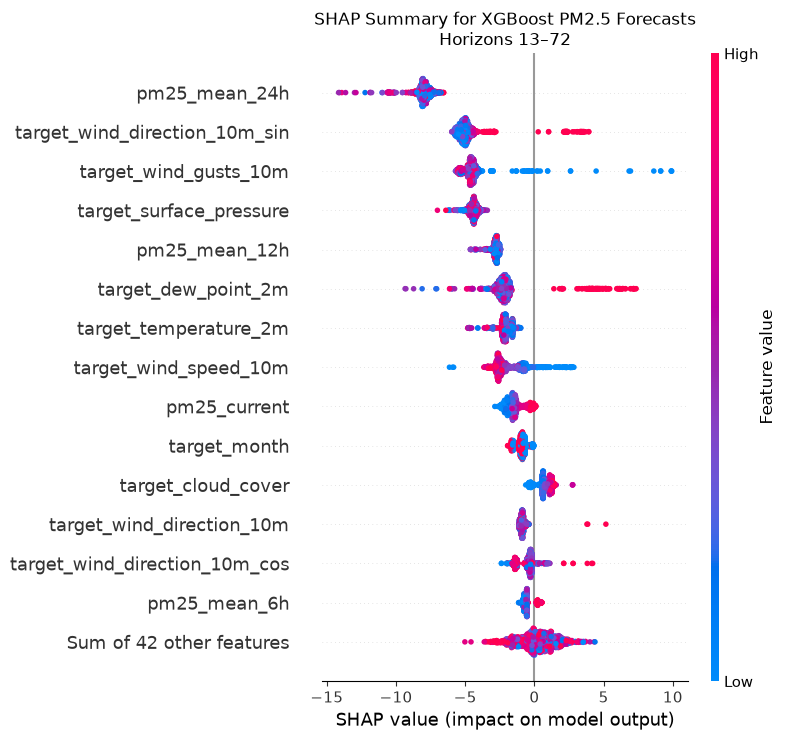

Saved SHAP summary figure: /home/riyan/Riyan/projects/pearls-aqi-predictor/figures/shap_summary.png


In [46]:
plt.figure()

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False,
)

plt.title(
    "SHAP Summary for XGBoost PM2.5 Forecasts\n"
    "Horizons 13–72"
)

plt.tight_layout()

plt.savefig(
    SHAP_SUMMARY_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved SHAP summary figure:",
    SHAP_SUMMARY_FIGURE_PATH,
)

### SHAP feature-importance bar plot

The SHAP bar plot summarizes the mean absolute contribution of each feature.

Unlike the beeswarm plot, it shows importance magnitude only and does not show
whether feature values push predictions upward or downward.

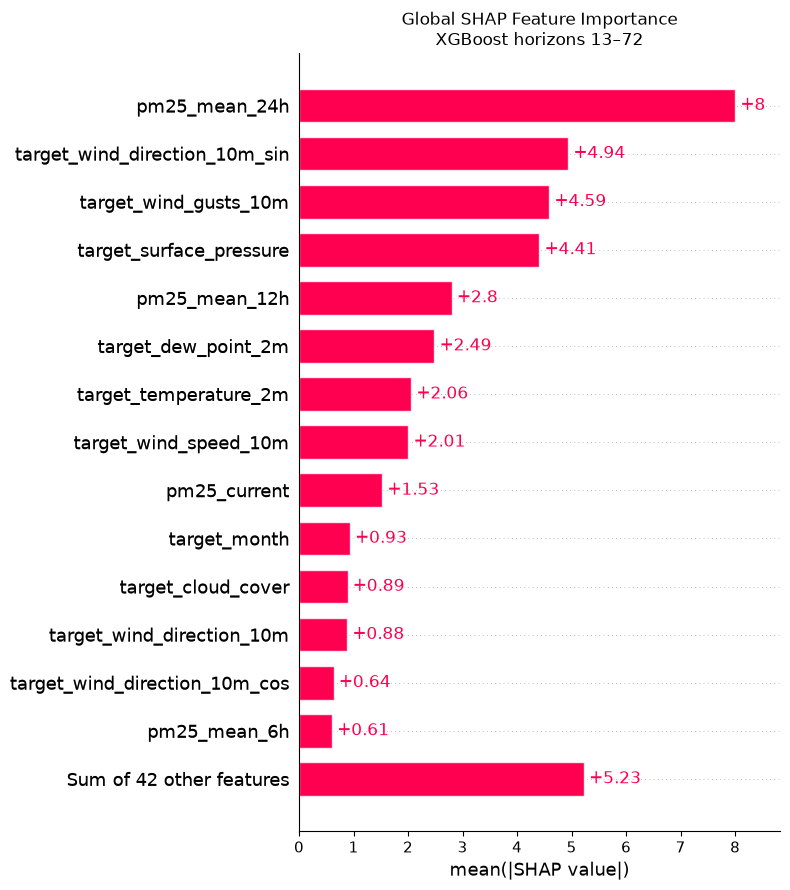

Saved SHAP feature-importance figure: /home/riyan/Riyan/projects/pearls-aqi-predictor/figures/shap_feature_importance.png


In [47]:
plt.figure()

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False,
)

plt.title(
    "Global SHAP Feature Importance\n"
    "XGBoost horizons 13–72"
)

plt.tight_layout()

plt.savefig(
    SHAP_FEATURE_IMPORTANCE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved SHAP feature-importance figure:",
    SHAP_FEATURE_IMPORTANCE_FIGURE_PATH,
)

### Compare gain, permutation, and SHAP rankings

The three methods answer related but different questions:

- gain shows which features improved tree splits
- permutation shows which features matter for predictive performance
- SHAP shows which features change individual predictions most strongly

Features ranking highly across several methods provide the strongest evidence
of consistent model reliance.

In [48]:
shap_ranking_df = (
    shap_global_importance_df[
        [
            "feature",
            "mean_absolute_shap",
            "normalized_shap_importance",
            "shap_rank",
        ]
    ]
    .copy()
)


three_method_importance_df = (
    importance_comparison_df
    .merge(
        shap_ranking_df,
        on="feature",
        how="inner",
        validate="one_to_one",
    )
)


three_method_importance_df[
    "three_method_average_rank"
] = (
    three_method_importance_df[
        [
            "gain_rank",
            "permutation_rank",
            "shap_rank",
        ]
    ]
    .mean(axis=1)
)


three_method_importance_df = (
    three_method_importance_df
    .sort_values(
        [
            "three_method_average_rank",
            "shap_rank",
        ]
    )
    .reset_index(drop=True)
)


display(
    three_method_importance_df[
        [
            "feature",
            "gain_rank",
            "permutation_rank",
            "shap_rank",
            "three_method_average_rank",
        ]
    ].head(20)
)

,feature,gain_rank,permutation_rank,shap_rank,three_method_average_rank
0,target_wind_gusts_10m,5,3,3,3.666667
1,target_wind_direction_10m_sin,6,6,2,4.666667
2,pm25_current,7,2,9,6.000000
3,pm25_mean_6h,3,5,14,7.333333
4,pm25_mean_12h,2,20,5,9.000000
5,target_wind_direction_10m_cos,11,4,13,9.333333
6,target_wind_speed_10m,22,1,8,10.333333
7,pm25_mean_3h,4,9,19,10.666667
8,target_temperature_2m,13,13,7,11.000000
9,target_hour_cos,8,8,18,11.333333


In [49]:
assert SHAP_GLOBAL_IMPORTANCE_PATH.exists()
assert SHAP_SUMMARY_FIGURE_PATH.exists()
assert SHAP_FEATURE_IMPORTANCE_FIGURE_PATH.exists()

assert len(shap_global_importance_df) == 56
assert shap_values.values.shape[0] == len(shap_sample_df)

assert (
    shap_global_importance_df[
        [
            "mean_absolute_shap",
            "mean_signed_shap",
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

print(
    "Phase 4C SHAP global explanation passed."
)

Phase 4C SHAP global explanation passed.


## **4D.** Focused error analysis and readiness conclusion

The core explainability requirement has been completed using:

- XGBoost gain importance
- permutation importance
- SHAP global explanations

This final section performs a compact error analysis to determine whether the
saved forecasting strategy is suitable for the live inference phase.

The analysis focuses on:

- model bias
- performance at different PM2.5 levels
- the largest test errors
- the main explainability findings
- limitations and readiness for live inference

No model retraining or additional tuning is performed.

In [50]:
ERROR_ANALYSIS_DIR = (
    PROJECT_ROOT
    / "error_analysis"
)

ERROR_ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


POLLUTION_BAND_METRICS_PATH = (
    ERROR_ANALYSIS_DIR
    / "metrics_by_pollution_band.csv"
)

LARGEST_ERRORS_PATH = (
    ERROR_ANALYSIS_DIR
    / "largest_errors.csv"
)

ERROR_ANALYSIS_REPORT_PATH = (
    ERROR_ANALYSIS_DIR
    / "phase_4_error_analysis_report.json"
)

EXPLAINABILITY_REPORT_PATH = (
    EXPLAINABILITY_DIR
    / "phase_4_explainability_report.json"
)

POLLUTION_BAND_FIGURE_PATH = (
    FIGURES_DIR
    / "error_by_pollution_band.png"
)


print("Error-analysis directory:", ERROR_ANALYSIS_DIR)

Error-analysis directory: /home/riyan/Riyan/projects/pearls-aqi-predictor/error_analysis


### Attach model features to the saved predictions

The saved test prediction table contains the final hybrid predictions and
errors.

It is joined with the test dataset so that the largest errors can be inspected
together with relevant PM2.5 history and weather conditions.

The join uses:

`reference_time + forecast_horizon_hours`

In [51]:
ANALYSIS_KEY_COLUMNS = [
    "reference_time",
    "forecast_horizon_hours",
]

analysis_feature_columns = [
    "reference_time",
    "forecast_horizon_hours",
    "target_time",
    "pm25_current",
    "pm25_lag_1h",
    "pm25_lag_6h",
    "pm25_lag_24h",
    "pm25_mean_6h",
    "pm25_mean_12h",
    "pm25_mean_24h",
    "pm25_change_1h",
    "pm25_change_6h",
    "pm25_change_24h",
    "target_temperature_2m",
    "target_relative_humidity_2m",
    "target_surface_pressure",
    "target_precipitation",
    "target_cloud_cover",
    "target_wind_speed_10m",
    "target_wind_direction_10m",
    "target_wind_gusts_10m",
]

available_analysis_feature_columns = [
    column
    for column in analysis_feature_columns
    if column in test_df.columns
]

phase_4_detailed_analysis_df = (
    phase_4_test_analysis_df
    .merge(
        test_df[
            available_analysis_feature_columns
        ],
        on=ANALYSIS_KEY_COLUMNS,
        how="left",
        suffixes=("", "_test"),
        validate="one_to_one",
    )
)

print(
    "Detailed analysis shape:",
    phase_4_detailed_analysis_df.shape,
)

assert len(
    phase_4_detailed_analysis_df
) == len(test_df)

print("Detailed test-analysis table created.")

Detailed analysis shape: (76813, 36)
Detailed test-analysis table created.


### Analyze performance by PM2.5 level

Test targets are divided into four practical PM2.5 bands:

- Low: below 12 µg/m³
- Moderate: 12 to below 35.5 µg/m³
- High: 35.5 to below 55.5 µg/m³
- Extreme: 55.5 µg/m³ and above

These bands are used only for model error analysis.

Formal PM2.5-to-AQI conversion will be implemented in a later phase.

In [52]:
POLLUTION_BAND_LABELS = [
    "low",
    "moderate",
    "high",
    "extreme",
]

phase_4_detailed_analysis_df[
    "pollution_band"
] = pd.cut(
    phase_4_detailed_analysis_df[
        "actual_pm25"
    ],
    bins=[
        -np.inf,
        12.0,
        35.5,
        55.5,
        np.inf,
    ],
    labels=POLLUTION_BAND_LABELS,
    right=False,
)

In [53]:
pollution_band_metric_records = []

for band_name in POLLUTION_BAND_LABELS:
    band_df = (
        phase_4_detailed_analysis_df.loc[
            phase_4_detailed_analysis_df[
                "pollution_band"
            ].eq(band_name)
        ]
    )

    if band_df.empty:
        continue

    pollution_band_metric_records.append(
        {
            "pollution_band": band_name,
            "rows": len(band_df),
            "actual_pm25_mean": float(
                band_df["actual_pm25"].mean()
            ),
            "predicted_pm25_mean": float(
                band_df["predicted_pm25"].mean()
            ),
            "mae": float(
                band_df["absolute_error"].mean()
            ),
            "rmse": float(
                np.sqrt(
                    band_df["squared_error"].mean()
                )
            ),
            "mean_residual": float(
                band_df["residual"].mean()
            ),
            "underprediction_rate": float(
                band_df[
                    "prediction_bias_direction"
                ]
                .eq("underprediction")
                .mean()
            ),
            "overprediction_rate": float(
                band_df[
                    "prediction_bias_direction"
                ]
                .eq("overprediction")
                .mean()
            ),
        }
    )


pollution_band_metrics_df = pd.DataFrame(
    pollution_band_metric_records
)

display(pollution_band_metrics_df)

,pollution_band,rows,actual_pm25_mean,predicted_pm25_mean,mae,rmse,mean_residual,underprediction_rate,overprediction_rate
0,low,48383,8.501143,10.899740,2.903770,4.062212,-2.398597,0.210508,0.786041
1,moderate,28394,16.832613,12.448624,5.079301,6.194566,4.383989,0.883708,0.114566
2,high,36,37.500000,18.488003,19.011997,19.473483,19.011997,1.000000,0.000000


In [54]:
pollution_band_metrics_df.to_csv(
    POLLUTION_BAND_METRICS_PATH,
    index=False,
)

print(
    "Saved pollution-band metrics:",
    POLLUTION_BAND_METRICS_PATH,
)

Saved pollution-band metrics: /home/riyan/Riyan/projects/pearls-aqi-predictor/error_analysis/metrics_by_pollution_band.csv


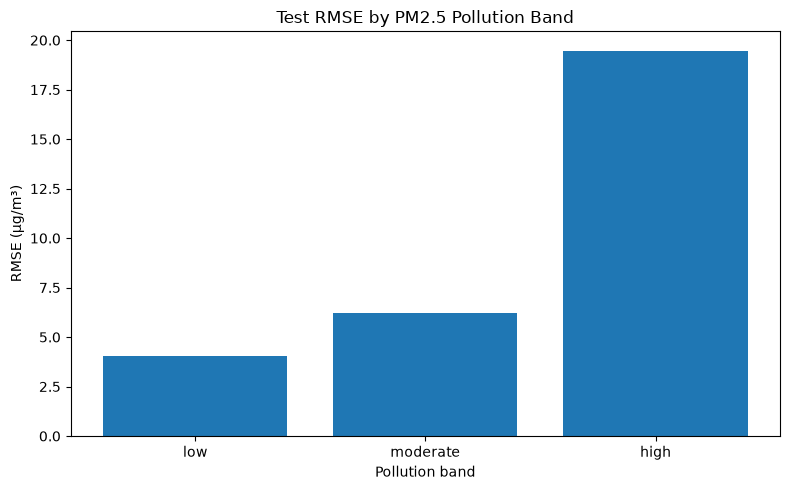

In [55]:
plot_pollution_band_df = (
    pollution_band_metrics_df
    .set_index("pollution_band")
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_pollution_band_df.index,
    plot_pollution_band_df["rmse"],
)

plt.xlabel("Pollution band")
plt.ylabel("RMSE (µg/m³)")
plt.title(
    "Test RMSE by PM2.5 Pollution Band"
)

plt.tight_layout()

plt.savefig(
    POLLUTION_BAND_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### Summarize overall prediction bias

Residual is defined as:

`actual PM2.5 - predicted PM2.5`

Therefore:

- positive residual means underprediction
- negative residual means overprediction

In [56]:
overall_bias_summary = {
    "test_rows": int(
        len(phase_4_detailed_analysis_df)
    ),
    "mean_actual_pm25": float(
        phase_4_detailed_analysis_df[
            "actual_pm25"
        ].mean()
    ),
    "mean_predicted_pm25": float(
        phase_4_detailed_analysis_df[
            "predicted_pm25"
        ].mean()
    ),
    "mean_residual": float(
        phase_4_detailed_analysis_df[
            "residual"
        ].mean()
    ),
    "median_residual": float(
        phase_4_detailed_analysis_df[
            "residual"
        ].median()
    ),
    "underprediction_rate": float(
        phase_4_detailed_analysis_df[
            "prediction_bias_direction"
        ]
        .eq("underprediction")
        .mean()
    ),
    "overprediction_rate": float(
        phase_4_detailed_analysis_df[
            "prediction_bias_direction"
        ]
        .eq("overprediction")
        .mean()
    ),
    "exact_prediction_rate": float(
        phase_4_detailed_analysis_df[
            "prediction_bias_direction"
        ]
        .eq("exact")
        .mean()
    ),
}

display(
    pd.Series(
        overall_bias_summary,
        name="value",
    ).to_frame()
)

,value
test_rows,76813.000000
mean_actual_pm25,11.594470
mean_predicted_pm25,11.475843
mean_residual,0.118627
median_residual,-0.400000
underprediction_rate,0.459727
overprediction_rate,0.537461
exact_prediction_rate,0.002812


### Inspect the largest test errors

The 20 largest absolute errors are inspected to identify patterns such as:

- sudden PM2.5 increases
- sudden PM2.5 decreases
- extreme pollution
- long forecast horizons
- unusual wind or weather conditions

The table supports investigation but does not prove that any individual
condition caused the error.

In [57]:
largest_error_columns = [
    "reference_time",
    "target_time",
    "forecast_horizon_hours",
    "actual_pm25",
    "predicted_pm25",
    "residual",
    "absolute_error",
    "prediction_bias_direction",
    "prediction_source",
    "pm25_current",
    "pm25_lag_1h",
    "pm25_lag_6h",
    "pm25_lag_24h",
    "pm25_mean_6h",
    "pm25_mean_12h",
    "pm25_mean_24h",
    "pm25_change_1h",
    "pm25_change_6h",
    "pm25_change_24h",
    "target_temperature_2m",
    "target_relative_humidity_2m",
    "target_precipitation",
    "target_wind_speed_10m",
    "target_wind_direction_10m",
    "target_wind_gusts_10m",
]

available_largest_error_columns = [
    column
    for column in largest_error_columns
    if column in phase_4_detailed_analysis_df.columns
]


largest_errors_df = (
    phase_4_detailed_analysis_df
    .nlargest(
        20,
        "absolute_error",
    )
    [
        available_largest_error_columns
    ]
    .reset_index(drop=True)
)

display(largest_errors_df)

,reference_time,target_time,forecast_horizon_hours,actual_pm25,predicted_pm25,residual,absolute_error,prediction_bias_direction,prediction_source,pm25_current,...,pm25_mean_24h,pm25_change_1h,pm25_change_6h,pm25_change_24h,target_temperature_2m,target_relative_humidity_2m,target_precipitation,target_wind_speed_10m,target_wind_direction_10m,target_wind_gusts_10m
0,2026-06-02 22:00:00+00:00,2026-06-03 10:00:00+00:00,12,5.2,37.5,-32.3,32.3,overprediction,current_persistence,37.5,...,13.183333,5.0,18.9,31.4,32.9,63.0,0.0,14.8,214.0,41.0
1,2026-06-02 22:00:00+00:00,2026-06-03 09:00:00+00:00,11,6.0,37.5,-31.5,31.5,overprediction,current_persistence,37.5,...,13.183333,5.0,18.9,31.4,33.1,61.0,0.0,13.5,205.0,38.2
2,2026-06-02 18:00:00+00:00,2026-06-02 22:00:00+00:00,4,37.5,6.9,30.6,30.6,underprediction,current_persistence,6.9,...,10.041667,-2.6,-6.4,0.0,28.3,79.0,0.0,3.9,298.0,14.0
3,2026-06-02 22:00:00+00:00,2026-06-03 08:00:00+00:00,10,9.3,37.5,-28.2,28.2,overprediction,current_persistence,37.5,...,13.183333,5.0,18.9,31.4,32.9,60.0,0.0,12.8,202.0,37.4
4,2026-06-02 17:00:00+00:00,2026-06-02 22:00:00+00:00,5,37.5,9.5,28.0,28.0,underprediction,current_persistence,9.5,...,10.041667,-9.1,-4.9,3.9,28.3,79.0,0.0,3.9,298.0,14.0
5,2026-06-02 23:00:00+00:00,2026-06-03 10:00:00+00:00,11,5.2,32.8,-27.6,27.6,overprediction,current_persistence,32.8,...,14.304167,-4.7,23.3,26.9,32.9,63.0,0.0,14.8,214.0,41.0
6,2026-06-02 19:00:00+00:00,2026-06-02 22:00:00+00:00,3,37.5,10.2,27.3,27.3,underprediction,current_persistence,10.2,...,10.191667,3.3,-4.5,3.6,28.3,79.0,0.0,3.9,298.0,14.0
7,2026-06-02 23:00:00+00:00,2026-06-03 09:00:00+00:00,10,6.0,32.8,-26.8,26.8,overprediction,current_persistence,32.8,...,14.304167,-4.7,23.3,26.9,33.1,61.0,0.0,13.5,205.0,38.2
8,2026-06-02 21:00:00+00:00,2026-06-03 09:00:00+00:00,12,6.0,32.5,-26.5,26.5,overprediction,current_persistence,32.5,...,11.875000,12.9,15.5,26.7,33.1,61.0,0.0,13.5,205.0,38.2
9,2026-06-02 18:00:00+00:00,2026-06-02 23:00:00+00:00,5,32.8,6.9,25.9,25.9,underprediction,current_persistence,6.9,...,10.041667,-2.6,-6.4,0.0,28.1,81.0,0.0,2.8,162.0,9.4


In [58]:
largest_errors_df.to_csv(
    LARGEST_ERRORS_PATH,
    index=False,
)

print(
    "Saved largest-error table:",
    LARGEST_ERRORS_PATH,
)

Saved largest-error table: /home/riyan/Riyan/projects/pearls-aqi-predictor/error_analysis/largest_errors.csv


### Summarize model drivers

The final explanation combines the evidence from:

- XGBoost gain importance
- permutation importance
- SHAP importance
- SHAP directional effects

Feature importance describes model reliance and association, not causation.

In [59]:
TOP_REPORT_FEATURE_COUNT = 10

top_shap_features = (
    shap_global_importance_df
    .head(TOP_REPORT_FEATURE_COUNT)
    [
        [
            "feature",
            "mean_absolute_shap",
            "normalized_shap_importance",
            "shap_rank",
        ]
    ]
    .to_dict(orient="records")
)

display(
    shap_global_importance_df.head(
        TOP_REPORT_FEATURE_COUNT
    )
)

,feature,mean_absolute_shap,mean_signed_shap,normalized_shap_importance,shap_rank
0,pm25_mean_24h,8.003045,-8.003045,0.190539,1
1,target_wind_direction_10m_sin,4.938950,-4.774541,0.117588,2
2,target_wind_gusts_10m,4.590964,-4.480601,0.109303,3
3,target_surface_pressure,4.410491,-4.410491,0.105006,4
4,pm25_mean_12h,2.802440,-2.802440,0.066721,5
5,target_dew_point_2m,2.485174,-1.871547,0.059168,6
6,target_temperature_2m,2.058661,-2.058661,0.049013,7
7,target_wind_speed_10m,2.006317,-1.861863,0.047767,8
8,pm25_current,1.526844,-1.525846,0.036351,9
9,target_month,0.933610,-0.933610,0.022228,10


### Main model-behavior findings

The XGBoost component mainly relies on two broad feature groups:

1. **Recent PM2.5 history**

   Rolling PM2.5 features such as the 24-hour, 12-hour, and 6-hour means provide
   information about the recent pollution level and its broader trend.

2. **Target-hour weather**

   Wind speed, wind gusts, wind direction, pressure, temperature, dew point,
   humidity, and cloud cover influence the model's medium- and long-horizon
   predictions.

The importance methods do not produce identical rankings because PM2.5 lag and
rolling features are strongly related and may substitute for one another.

SHAP results show associations between feature values and predictions, but they
must not be interpreted as proof that a feature causes pollution changes.

The hybrid routing remains straightforward:

- short horizons rely directly on current PM2.5
- longer horizons combine pollution history, weather, and time features through
  XGBoost

In [60]:
PHASE_4_APPROVAL_STATUS = (
    "APPROVED_WITH_LIMITATIONS"
)

In [61]:
phase_4_explainability_report = {
    "phase": "Phase 4 - Model explainability",
    "model_loaded": True,
    "model_type": type(saved_model).__name__,
    "selected_strategy": SELECTED_STRATEGY_NAME,
    "xgboost_horizons": "13-72",
    "persistence_horizons": "1-12",
    "test_rows_available": int(len(test_df)),
    "shap_sample_size": int(
        len(shap_sample_df)
    ),
    "shap_sampling_strategy": (
        "Balanced sample of 500 rows from each "
        "XGBoost horizon group: 13-24h, 25-48h, "
        "and 49-72h."
    ),
    "explainability_methods": [
        "xgboost_gain_importance",
        "permutation_importance",
        "tree_shap",
    ],
    "shap_prediction_reconstruction": {
        "maximum_absolute_difference": float(
            reconstruction_difference.max()
        ),
        "mean_absolute_difference": float(
            reconstruction_difference.mean()
        ),
    },
    "top_global_features_by_shap": (
        top_shap_features
    ),
    "main_findings": [
        (
            "Recent PM2.5 rolling history is a major "
            "driver of long-horizon predictions."
        ),
        (
            "Target-hour wind conditions are important "
            "for XGBoost predictive performance."
        ),
        (
            "Current PM2.5 remains an important model "
            "input beyond the persistence-only horizons."
        ),
        (
            "Weather and time features contribute to "
            "medium- and long-range predictions."
        ),
        (
            "Feature importance represents model "
            "association and does not prove causation."
        ),
    ],
    "limitations": [
        (
            "SHAP was calculated on a representative "
            "sample rather than every test row."
        ),
        (
            "Correlated lag and rolling features can "
            "share importance across methods."
        ),
        (
            "Sine and cosine wind-direction features "
            "must be interpreted together."
        ),
        (
            "Observed historical target-hour weather "
            "was used during model evaluation."
        ),
    ],
    "approval_status": PHASE_4_APPROVAL_STATUS,
}

with open(
    EXPLAINABILITY_REPORT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        phase_4_explainability_report,
        file,
        indent=2,
        default=str,
    )

print(
    "Saved explainability report:",
    EXPLAINABILITY_REPORT_PATH,
)

Saved explainability report: /home/riyan/Riyan/projects/pearls-aqi-predictor/explainability/phase_4_explainability_report.json


In [62]:
largest_error_summary = {
    "maximum_absolute_error": float(
        largest_errors_df[
            "absolute_error"
        ].max()
    ),
    "largest_underprediction": float(
        phase_4_detailed_analysis_df[
            "residual"
        ].max()
    ),
    "largest_overprediction": float(
        phase_4_detailed_analysis_df[
            "residual"
        ].min()
    ),
    "largest_error_median_horizon": float(
        largest_errors_df[
            "forecast_horizon_hours"
        ].median()
    ),
}

phase_4_error_analysis_report = {
    "phase": "Phase 4 - Focused error analysis",
    "selected_strategy": SELECTED_STRATEGY_NAME,
    "test_rows_analyzed": int(
        len(phase_4_detailed_analysis_df)
    ),
    "overall_metrics": (
        reproduced_test_metrics
    ),
    "overall_bias": (
        overall_bias_summary
    ),
    "pollution_band_metrics": (
        pollution_band_metrics_df
        .to_dict(orient="records")
    ),
    "largest_error_summary": (
        largest_error_summary
    ),
    "sensor_gap_analysis": {
        "performed": False,
        "reason": (
            "Skipped in the compact explainability phase. "
            "The model-ready test dataset already excludes "
            "rows with incomplete required PM2.5 history."
        ),
    },
    "limitations": [
        (
            "The test period was easier than the "
            "validation period and contained different "
            "PM2.5 variability."
        ),
        (
            "Test R² was close to zero despite improved "
            "MAE and RMSE over persistence."
        ),
        (
            "Extreme PM2.5 events contain fewer examples "
            "and may have less reliable error estimates."
        ),
        (
            "Production performance will also depend on "
            "Open-Meteo forecast accuracy."
        ),
    ],
    "approval_status": PHASE_4_APPROVAL_STATUS,
    "approval_justification": (
        "The saved hybrid strategy is reproducible, "
        "outperformed persistence on untouched test RMSE, "
        "produced physically valid predictions, and showed "
        "reasonable feature reliance. It is approved for "
        "live inference with documented limitations."
    ),
}

with open(
    ERROR_ANALYSIS_REPORT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        phase_4_error_analysis_report,
        file,
        indent=2,
        default=str,
    )

print(
    "Saved error-analysis report:",
    ERROR_ANALYSIS_REPORT_PATH,
)

Saved error-analysis report: /home/riyan/Riyan/projects/pearls-aqi-predictor/error_analysis/phase_4_error_analysis_report.json


In [63]:
phase_4_artifact_paths = {
    "global_gain_importance": (
        GLOBAL_IMPORTANCE_PATH
    ),
    "permutation_importance": (
        PERMUTATION_IMPORTANCE_PATH
    ),
    "shap_global_importance": (
        SHAP_GLOBAL_IMPORTANCE_PATH
    ),
    "pollution_band_metrics": (
        POLLUTION_BAND_METRICS_PATH
    ),
    "largest_errors": (
        LARGEST_ERRORS_PATH
    ),
    "explainability_report": (
        EXPLAINABILITY_REPORT_PATH
    ),
    "error_analysis_report": (
        ERROR_ANALYSIS_REPORT_PATH
    ),
    "gain_figure": (
        GLOBAL_IMPORTANCE_FIGURE_PATH
    ),
    "permutation_figure": (
        PERMUTATION_IMPORTANCE_FIGURE_PATH
    ),
    "shap_summary_figure": (
        SHAP_SUMMARY_FIGURE_PATH
    ),
    "shap_importance_figure": (
        SHAP_FEATURE_IMPORTANCE_FIGURE_PATH
    ),
    "pollution_band_figure": (
        POLLUTION_BAND_FIGURE_PATH
    ),
}


phase_4_artifact_summary_df = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "exists": artifact_path.exists(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.exists()
                else None
            ),
            "path": str(artifact_path),
        }
        for artifact_name, artifact_path
        in phase_4_artifact_paths.items()
    ]
)

display(phase_4_artifact_summary_df)


assert (
    phase_4_artifact_summary_df[
        "exists"
    ].all()
)

assert len(
    pollution_band_metrics_df
) >= 1

assert len(largest_errors_df) == 20

assert (
    PHASE_4_APPROVAL_STATUS
    == "APPROVED_WITH_LIMITATIONS"
)

print("All Phase 4 artifacts validated successfully.")

print(
    "Phase 4 readiness status:",
    PHASE_4_APPROVAL_STATUS,
)

,artifact,exists,size_bytes,path
0,global_gain_importance,True,2912,/home/riyan/Riyan/projects/pearls-aqi-predicto...
1,permutation_importance,True,4560,/home/riyan/Riyan/projects/pearls-aqi-predicto...
2,shap_global_importance,True,3202,/home/riyan/Riyan/projects/pearls-aqi-predicto...
3,pollution_band_metrics,True,506,/home/riyan/Riyan/projects/pearls-aqi-predicto...
4,largest_errors,True,5522,/home/riyan/Riyan/projects/pearls-aqi-predicto...
5,explainability_report,True,3351,/home/riyan/Riyan/projects/pearls-aqi-predicto...
6,error_analysis_report,True,2838,/home/riyan/Riyan/projects/pearls-aqi-predicto...
7,gain_figure,True,127901,/home/riyan/Riyan/projects/pearls-aqi-predicto...
8,permutation_figure,True,144614,/home/riyan/Riyan/projects/pearls-aqi-predicto...
9,shap_summary_figure,True,262556,/home/riyan/Riyan/projects/pearls-aqi-predicto...


All Phase 4 artifacts validated successfully.
Phase 4 readiness status: APPROVED_WITH_LIMITATIONS
